# Détecter des faux billets avec Python

## 0) Introduction et contexte métier


Ce notebook présente une démarche de data analysis et de machine learning visant à détecter des faux billets à partir de mesures physiques. Plusieurs modèles sont entraînés et comparés afin de sélectionner le plus pertinen.


## 1) Chargement des données 

In [1]:
#importation des librairies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore
from scipy.stats import mannwhitneyu, ttest_ind, fisher_exact, chi2_contingency
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.stats.multitest import multipletests
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression, RidgeCV, BayesianRidge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, recall_score, accuracy_score, f1_score, roc_auc_score, classification_report, mean_absolute_error, mean_squared_error
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import joblib
import json

In [2]:
# lecture du DataFrame 'billets.csv' : df
df= pd.read_csv('billets.csv', sep=';')

In [3]:
# Dimensions et aperçu du df
print(f"Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")
df.head()

Dataset chargé : 1500 lignes, 7 colonnes


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


## 2) Analyse exploratoire (EDA)

### 2.1) Présentation générale du dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB


### 2.2) Qualité des données

In [5]:
# Valeurs manquantes
df.isna().sum()

is_genuine       0
diagonal         0
height_left      0
height_right     0
margin_low      37
margin_up        0
length           0
dtype: int64

Il y a 37 valeurs manquantes dans la variable margin_low

In [6]:
# Taux de valeurs manquantes
missing_rate = df["margin_low"].isna().mean() * 100
print(f"Taux de valeurs manquantes pour margin_low : {missing_rate:.2f} %")

Taux de valeurs manquantes pour margin_low : 2.47 %


In [7]:
# Doublons (hors variable cible)
target = "is_genuine"
features_cols = df.columns.drop(target)

df.duplicated(subset=features_cols).sum()

0

In [8]:
df.describe()

,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.000000,1500.000000,1500.000000,1463.000000,1500.000000,1500.00000
mean,171.958440,104.029533,103.920307,4.485967,3.151473,112.67850
std,0.305195,0.299462,0.325627,0.663813,0.231813,0.87273
min,171.040000,103.140000,102.820000,2.980000,2.270000,109.49000
25%,171.750000,103.820000,103.710000,4.015000,2.990000,112.03000
50%,171.960000,104.040000,103.920000,4.310000,3.140000,112.96000
75%,172.170000,104.230000,104.150000,4.870000,3.310000,113.34000
max,173.010000,104.880000,104.950000,6.900000,3.910000,114.44000


Les statistiques descriptives montrent des ordres de grandeur cohérents pour l’ensemble des variables. Aucune valeur aberrante ou incohérente n’est détectée à ce stade. La variable 'margin_low' est la seule à présenter des valeurs manquantes (2,47 %), tandis que les autres variables sont complètes. La qualité globale des données est jugée satisfaisante pour poursuivre l’analyse exploratoire.


### 2.3) Analyse univariée

In [9]:
# Statistiques descriptives
df.describe()

,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.000000,1500.000000,1500.000000,1463.000000,1500.000000,1500.00000
mean,171.958440,104.029533,103.920307,4.485967,3.151473,112.67850
std,0.305195,0.299462,0.325627,0.663813,0.231813,0.87273
min,171.040000,103.140000,102.820000,2.980000,2.270000,109.49000
25%,171.750000,103.820000,103.710000,4.015000,2.990000,112.03000
50%,171.960000,104.040000,103.920000,4.310000,3.140000,112.96000
75%,172.170000,104.230000,104.150000,4.870000,3.310000,113.34000
max,173.010000,104.880000,104.950000,6.900000,3.910000,114.44000


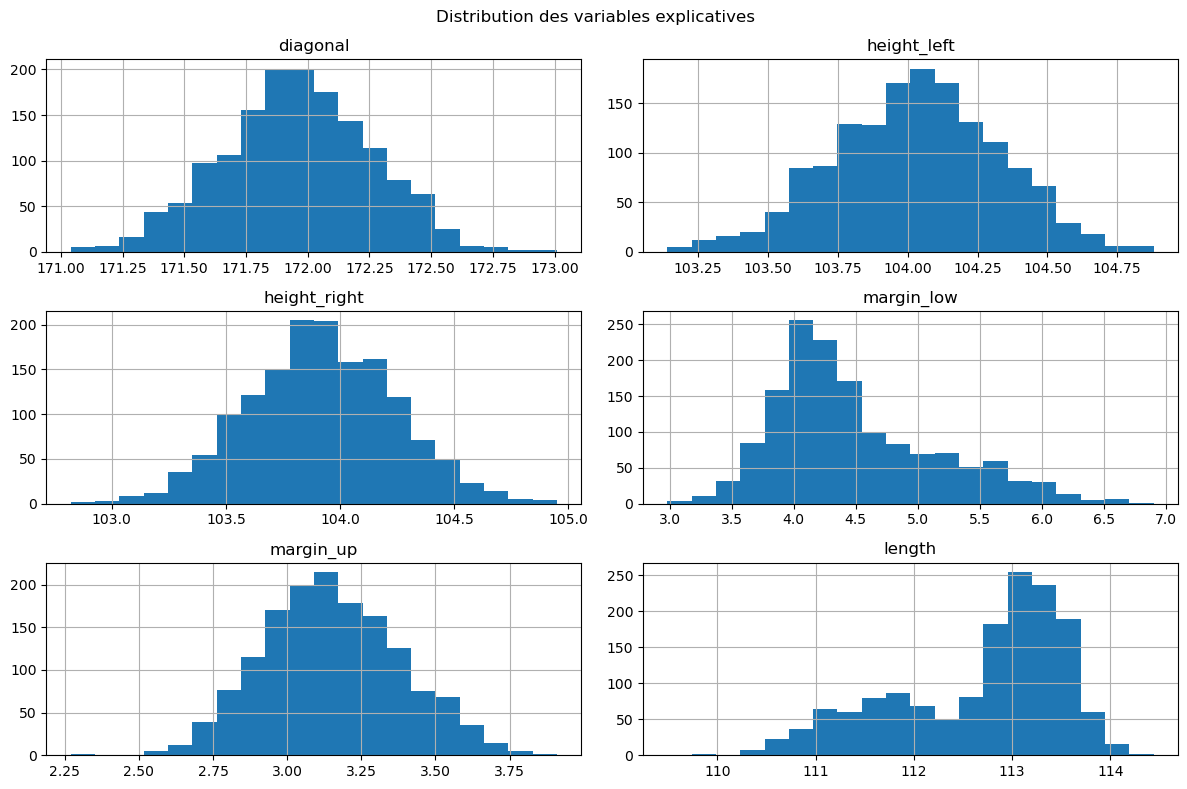

In [10]:
# Histogramme de chacune des variables
df[features_cols].hist(figsize=(12, 8), bins=20)
plt.suptitle("Distribution des variables explicatives")
plt.tight_layout()
plt.savefig("distribution_variables.png", dpi=300, bbox_inches="tight")
plt.show()

Les boxplots mettent en évidence des ordres de grandeurs très différentes entre les variables. Cette observation confirme la nécessité d’une mise à l’échelle des données avant l’utilisation de modèles sensibles aux distances.


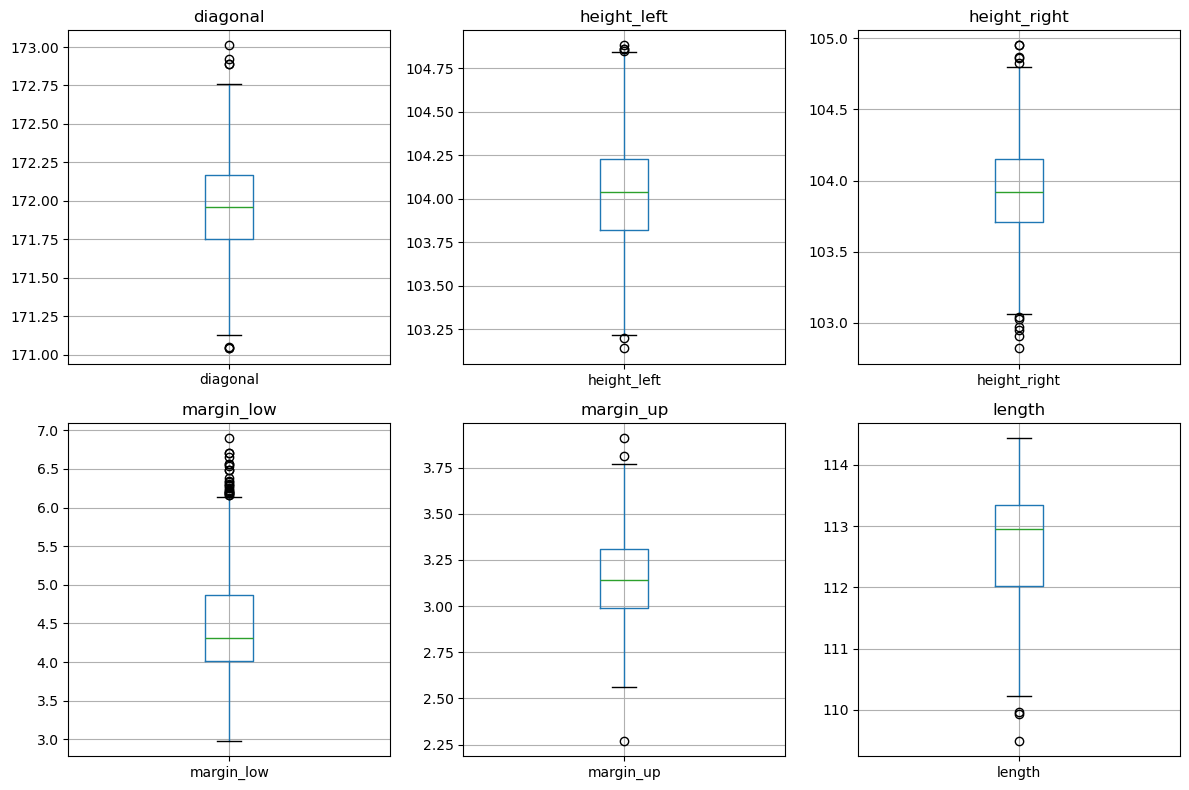

In [11]:
# Boxplot de chacune des variables
cols = list(features_cols)
n = len(cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4*nrows))

for ax, col in zip(axes.flatten(), cols):
    df.boxplot(column=col, ax=ax, showfliers=True)
    ax.set_title(col)
    ax.set_xlabel("")

plt.tight_layout()
plt.savefig("boxplot_variables.png", dpi=300, bbox_inches="tight")
plt.show()

Les boxplots individuels mettent en évidence la présence de quelques valeurs atypiques pour certaines variables, notamment 'margin_low'. Ces outliers sont définis au sens statistique et restent dans des plages de valeurs cohérentes d’un point de vue métier. Aucune suppression n’est effectuée à ce stade ; leur impact sera pris en compte lors de la phase de modélisation.

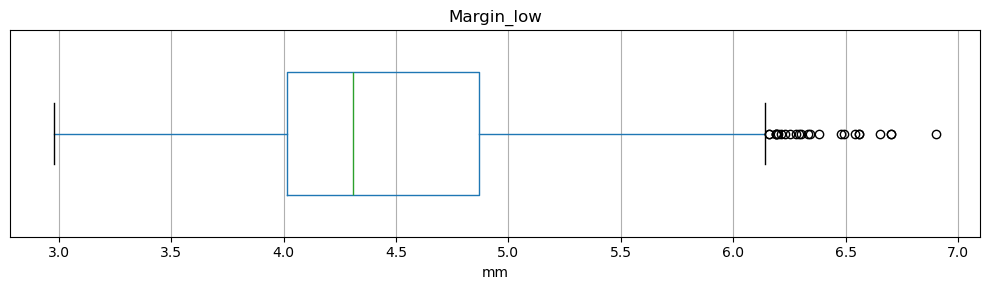

In [12]:
# Affichage de 'margin_low'
plt.figure(figsize=(10, 3))
df.boxplot(column="margin_low", vert=False, showfliers=True, widths=0.6)
plt.title("Margin_low")
plt.xlabel("mm")
plt.yticks([])
plt.tight_layout()
plt.savefig("marginlow_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
df.describe()

,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.000000,1500.000000,1500.000000,1463.000000,1500.000000,1500.00000
mean,171.958440,104.029533,103.920307,4.485967,3.151473,112.67850
std,0.305195,0.299462,0.325627,0.663813,0.231813,0.87273
min,171.040000,103.140000,102.820000,2.980000,2.270000,109.49000
25%,171.750000,103.820000,103.710000,4.015000,2.990000,112.03000
50%,171.960000,104.040000,103.920000,4.310000,3.140000,112.96000
75%,172.170000,104.230000,104.150000,4.870000,3.310000,113.34000
max,173.010000,104.880000,104.950000,6.900000,3.910000,114.44000


Étude statistique : margin_low
Nb total d'observations     : 1500
Nb valeurs non manquantes   : 1463
Nb valeurs manquantes (NaN) : 37 (2.47%)

Quartiles & IQR :
Q1  (25%)   = 4.0150
Q2  (50%)   = 4.3100  (médiane)
Q3  (75%)   = 4.8700
IQR         = 0.8550
Bornes IQR   = [2.7325 ; 6.1525]
Outliers IQR = 24 (1.64% des valeurs non manquantes)



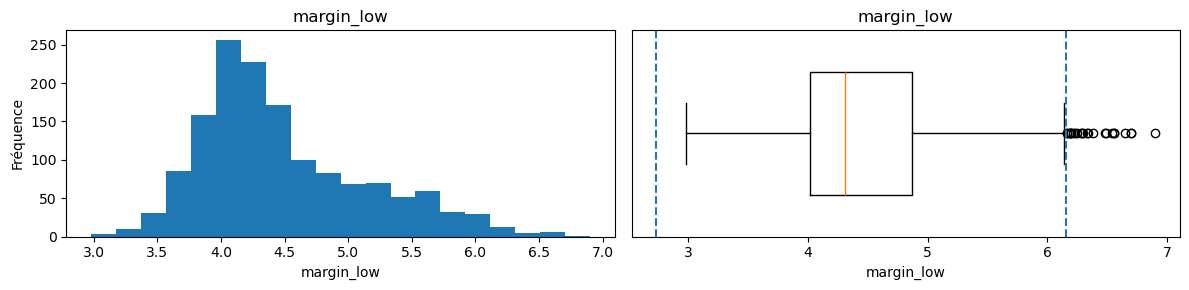

Top 5 valeurs les plus élevées :
6.90
6.70
6.70
6.65
6.56
      is_genuine  margin_low  diagonal  height_left  height_right  margin_up  \
1023       False        6.20    172.02       104.26        104.20       3.58   
1027       False        6.70    171.63       104.02        104.66       3.28   
1031       False        6.33    172.40       104.00        103.82       3.10   
1041       False        6.65    171.77       104.12        104.42       3.63   
1053       False        6.21    171.85       104.52        104.05       3.43   
1075       False        6.23    172.02       104.51        103.69       3.39   
1092       False        6.30    171.87       104.76        104.02       3.61   
1110       False        6.56    171.73       104.32        104.07       3.30   
1124       False        6.70    171.88       103.92        104.27       3.11   
1133       False        6.16    171.79       103.99        103.67       3.52   
1134       False        6.34    171.91       103.70        104

In [14]:
# Valeurs non manquantes
s = df["margin_low"].dropna()

n_total = len(df)
n_non_null = len(s)
n_missing = df["margin_low"].isna().sum()

print("Étude statistique : margin_low")
print(f"Nb total d'observations     : {n_total}")
print(f"Nb valeurs non manquantes   : {n_non_null}")
print(f"Nb valeurs manquantes (NaN) : {n_missing} ({n_missing/n_total:.2%})\n")

# Quartiles + IQR
q1 = s.quantile(0.25)
q2 = s.quantile(0.50)  
q3 = s.quantile(0.75)
iqr = q3 - q1

low_iqr = q1 - 1.5 * iqr
high_iqr = q3 + 1.5 * iqr

out_iqr_mask = (s < low_iqr) | (s > high_iqr)
n_out_iqr = int(out_iqr_mask.sum())
pct_out_iqr = n_out_iqr / n_non_null

print("Quartiles & IQR :")
print(f"Q1  (25%)   = {q1:.4f}")
print(f"Q2  (50%)   = {q2:.4f}  (médiane)")
print(f"Q3  (75%)   = {q3:.4f}")
print(f"IQR         = {iqr:.4f}")
print(f"Bornes IQR   = [{low_iqr:.4f} ; {high_iqr:.4f}]")
print(f"Outliers IQR = {n_out_iqr} ({pct_out_iqr:.2%} des valeurs non manquantes)\n")

# Visualisations 
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# Histogramme
axes[0].hist(s, bins=20)
axes[0].set_title("margin_low")
axes[0].set_xlabel("margin_low")
axes[0].set_ylabel("Fréquence")

# Boxplot horizontal + bornes IQR
axes[1].boxplot(s, vert=False, showfliers=True, widths=0.6)
axes[1].set_title("margin_low")
axes[1].set_xlabel("margin_low")
axes[1].set_yticks([])  # retire le label à gauche

# lignes bornes IQR 
axes[1].axvline(low_iqr, linestyle="--")
axes[1].axvline(high_iqr, linestyle="--")

plt.tight_layout()
plt.savefig("magin_low.png", dpi=300, bbox_inches="tight")
plt.show()

# 6) Afficher les 5 plus grandes valeurs 
print("Top 5 valeurs les plus élevées :")
print(s.sort_values(ascending=False).head(5).to_string(index=False))

# Masque outliers sur df 
mask_outliers = df["margin_low"].notna() & ((df["margin_low"] < low_iqr) | (df["margin_low"] > high_iqr))

# Afficher les observations outliers 
outliers_df = df.loc[mask_outliers, ["is_genuine", "margin_low", "diagonal", "height_left", "height_right", "margin_up", "length"]]
outliers_df.sort_values("margin_low", ascending=False)

print(outliers_df)
print("Répartition is_genuine parmi les outliers :")
print(df.loc[mask_outliers, "is_genuine"].value_counts())

La détection d’outliers par la règle IQR sur margin_low met en évidence 24 observations atypiques. L’analyse de ces observations montre qu’elles correspondent toutes à des billets contrefaits (is_genuine=False). Cela suggère que des valeurs extrêmes de margin_low constituent un signal très discriminant pour la détection des faux billets. Ces observations sont donc conservées, car elles portent une information utile plutôt que du bruit à supprimer.

### 2.4) Analyse de la variable cible

In [15]:
df[target].dtype, df[target].unique()

(dtype('bool'), array([ True, False]))

In [16]:
df[target].value_counts()

is_genuine
True     1000
False     500
Name: count, dtype: int64

In [17]:
(df[target].value_counts(normalize=True) * 100).round(2)

is_genuine
True     66.67
False    33.33
Name: proportion, dtype: float64

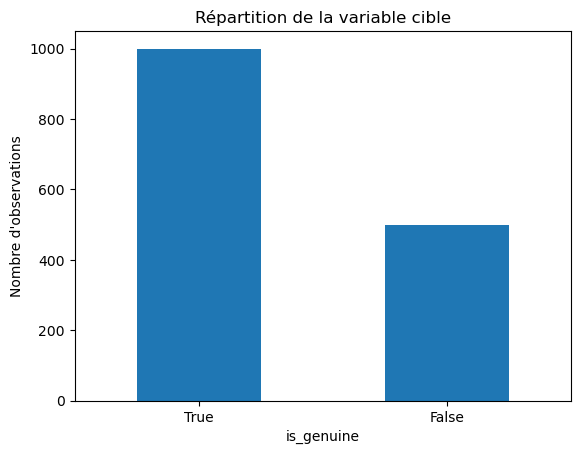

In [18]:
ax = df[target].value_counts().plot(kind="bar", rot=0)
plt.title("Répartition de la variable cible")
plt.xlabel("is_genuine")
plt.ylabel("Nombre d'observations")
plt.savefig("repartition_variable_cible.png", dpi=300, bbox_inches="tight")
plt.show()

La variable cible 'is_genuine' est binaire (booléenne). La répartition des classes est modérément déséquilibrée : 66,67 % de billets authentiques (True) contre 33,33 % de billets contrefaits (False). Ce déséquilibre sera pris en compte lors de l’évaluation des modèles, notamment via la matrice de confusion et les métriques précision/rappel.

### 2.5) Analyse bivariée

In [19]:
summary = df.groupby(target)[features_cols].agg(["mean", "median", "std"])
summary.round(2)

diagonal               height_left               height_right  \
               mean  median   std        mean  median   std         mean   
is_genuine                                                                 
False        171.90  171.91  0.31      104.19  104.18  0.22       104.14   
True         171.99  171.99  0.30      103.95  103.95  0.30       103.81   

                         margin_low              margin_up               \
            median   std       mean median   std      mean median   std   
is_genuine                                                                
False       104.16  0.27       5.22   5.19  0.55      3.35   3.35  0.18   
True        103.81  0.29       4.12   4.11  0.32      3.05   3.05  0.19   

            length                
              mean  median   std  
is_genuine                        
False       111.63  111.63  0.62  
True        113.20  113.20  0.36

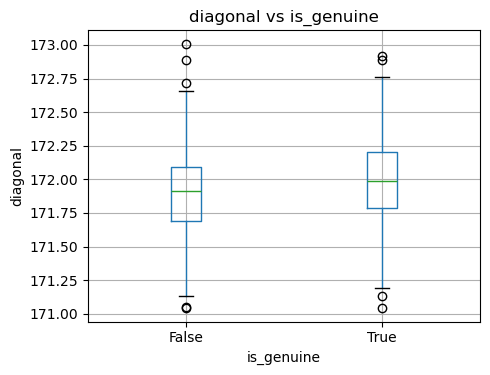

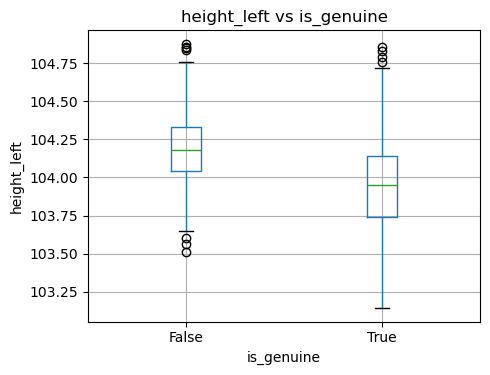

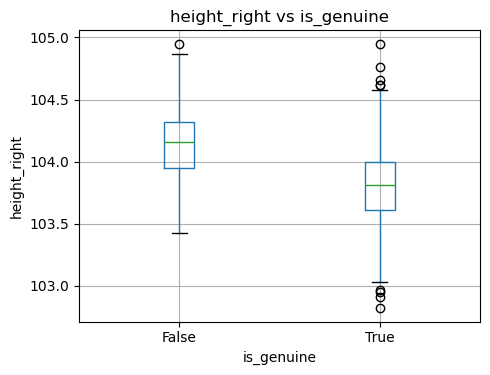

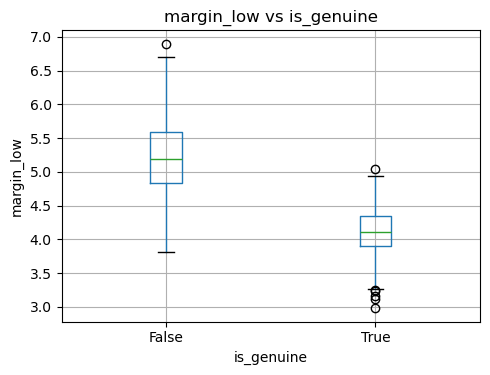

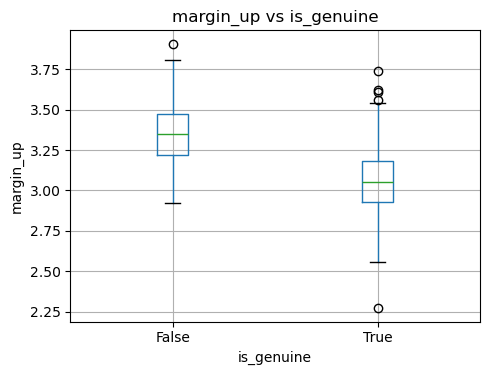

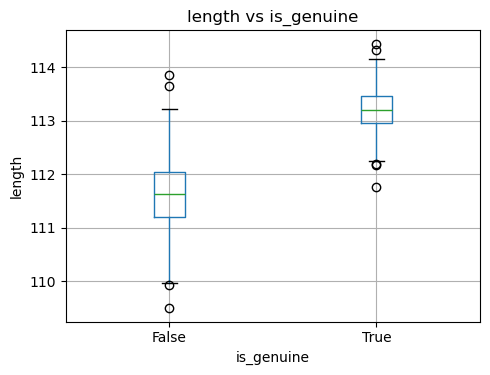

In [20]:
for col in features_cols:
    df.boxplot(column=col, by=target, figsize=(5, 4), showfliers=True)
    plt.title(f"{col} vs {target}")
    plt.suptitle("")
    plt.xlabel(target)
    plt.ylabel(col)
    plt.tight_layout()
    plt.savefig(f"boxplot_{col}_bivarie.png", dpi=300, bbox_inches="tight")
    plt.show()

In [21]:
#Calcul de la difference asolue pour chacune des variables entre vrais et faux billets
mean_diff = df.groupby(target)[features_cols].mean().T
mean_diff["diff_abs"] = (mean_diff[True] - mean_diff[False]).abs()
mean_diff.sort_values("diff_abs", ascending=False)

is_genuine,False,True,diff_abs
length,111.630640,113.202430,1.571790
margin_low,5.215935,4.116097,1.099838
height_right,104.143620,103.808650,0.334970
margin_up,3.350160,3.052130,0.298030
height_left,104.190340,103.949130,0.241210
diagonal,171.901160,171.987080,0.085920


L’analyse bivariée met en évidence des différences de distribution entre les classes. Les variables 'length' et 'margin_low' présentent les écarts moyens les plus importants entre billets authentiques et contrefaits, suggérant un fort pouvoir discriminant. À l’inverse, 'diagonal' semble moins différenciante. Ces observations seront confirmées lors de la phase de modélisation.


In [22]:
num_cols = ["diagonal", "height_left", "height_right", "margin_up", "length", "margin_low"]  

corr_s = df[num_cols].corr(method="spearman")
corr_p = df[num_cols].corr(method="pearson")

print("Corrélation Spearman:\n", corr_s.round(2))
print("\nCorrélation Pearson:\n", corr_p.round(2))

Corrélation Spearman:
               diagonal  height_left  height_right  margin_up  length  \
diagonal          1.00         0.02         -0.03      -0.05    0.10   
height_left       0.02         1.00          0.25       0.26   -0.31   
height_right     -0.03         0.25          1.00       0.30   -0.37   
margin_up        -0.05         0.26          0.30       1.00   -0.48   
length            0.10        -0.31         -0.37      -0.48    1.00   
margin_low       -0.10         0.30          0.40       0.42   -0.59   

              margin_low  
diagonal           -0.10  
height_left         0.30  
height_right        0.40  
margin_up           0.42  
length             -0.59  
margin_low          1.00  

Corrélation Pearson:
               diagonal  height_left  height_right  margin_up  length  \
diagonal          1.00         0.02         -0.02      -0.06    0.10   
height_left       0.02         1.00          0.24       0.25   -0.32   
height_right     -0.02         0.24         

### 2.6) Analyse multivariée

#### Tests Statistiques

In [23]:
# Test de Mann_Whitey + taille d'effet

def cliffs_delta(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    return (np.sum(a[:, None] > b[None, :]) - np.sum(a[:, None] < b[None, :])) / (len(a) * len(b))

vars_to_test = ["length", "margin_low", "margin_up", "height_right", "height_left", "diagonal"]

rows = []
for var in vars_to_test:
    x_true  = df.loc[df["is_genuine"] == True, var].dropna()
    x_false = df.loc[df["is_genuine"] == False, var].dropna()

    U, p = mannwhitneyu(x_true, x_false, alternative="two-sided")
    delta = cliffs_delta(x_true.values, x_false.values)

    rows.append({
        "variable": var,
        "n_true": len(x_true),
        "n_false": len(x_false),
        "median_true": x_true.median(),
        "median_false": x_false.median(),
        "U_stat": U,
        "p_value": p,
        "cliffs_delta": delta
    })

mw_df = pd.DataFrame(rows).sort_values("p_value")
mw_df

,variable,n_true,n_false,median_true,median_false,U_stat,p_value,cliffs_delta
0,length,1000,500,113.205,111.63,491978.5,1.288000e-205,0.967914
1,margin_low,971,492,4.110,5.19,19094.0,3.046593e-182,-0.920064
2,margin_up,1000,500,3.050,3.35,63494.0,5.419133e-123,-0.746024
3,height_right,1000,500,103.810,104.16,99224.5,4.807965e-81,-0.603102
4,height_left,1000,500,103.950,104.18,128779.0,4.883939e-53,-0.484884
5,diagonal,1000,500,171.990,171.91,289509.0,5.850271e-07,0.158036


Les tests de Mann–Whitney montrent que les distributions de length, margin_low, margin_up, height_right, height_left et diagonal diffèrent significativement entre vrais et faux billets (p-values < 0,05). Les écarts les plus marqués concernent length (plus faible chez les faux) et margin_low / margin_up (plus élevées chez les faux), ce qui confirme leur fort pouvoir discriminant pour la détection.

Le test de taille d'effet (Cliffs Delta) montre que : 
- length est nettement plus grande chez les vrais billets (+0.968)
- margin_low est nettement plus grande chez les faux billets (-0.920)
- margin_up est plus grande chez les faux billets (-0.746)

In [24]:
# Test de Fischer 
ct = pd.crosstab(mask_outliers, df["is_genuine"])
print(ct)

table = ct.reindex(index=[False, True], columns=[True, False], fill_value=0).values
_, p_value = fisher_exact(table)

print("Fisher p-value:", p_value)

is_genuine  False  True 
margin_low              
False         476   1000
True           24      0
Fisher p-value: 2.431328036897302e-12


Le test de Fisher rejette l’hypothèse nulle d’indépendance (p-value très inférieur a  0,05). On conclut à une association significative entre le statut d’outlier de margin_low et la contrefaçon.

In [25]:
# Matrice de corrélation
corr = df[features_cols].corr()
corr.round(2)

,diagonal,height_left,height_right,margin_low,margin_up,length
diagonal,1.00,0.02,-0.02,-0.11,-0.06,0.10
height_left,0.02,1.00,0.24,0.30,0.25,-0.32
height_right,-0.02,0.24,1.00,0.39,0.31,-0.40
margin_low,-0.11,0.30,0.39,1.00,0.43,-0.67
margin_up,-0.06,0.25,0.31,0.43,1.00,-0.52
length,0.10,-0.32,-0.40,-0.67,-0.52,1.00


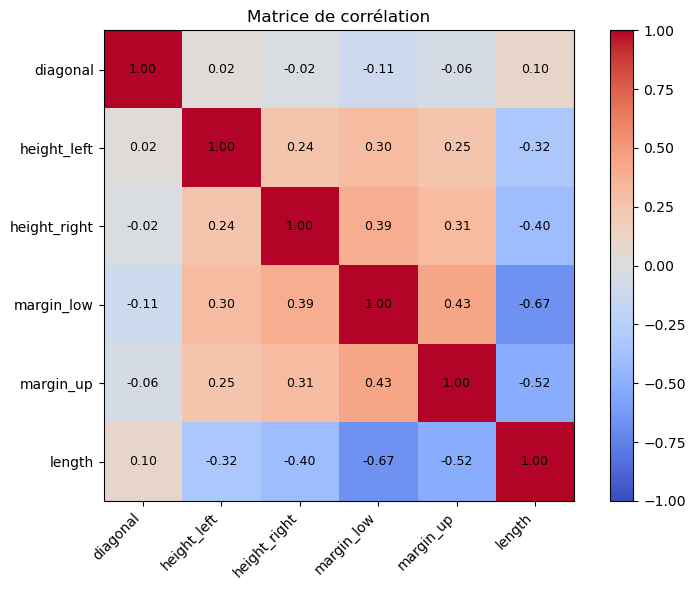

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)

fig.colorbar(im, ax=ax)
ax.set_title("Matrice de corrélation")
plt.tight_layout()
plt.savefig("heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

La matrice de corrélation met en évidence des relations notables entre certaines variables, en particulier une corrélation négative marquée entre 'length' et 'margin_low' (env -0,67), ainsi qu’entre 'length' et 'margin_up' (env -0,52). On observe également une corrélation positive modérée entre 'margin_low' et 'margin_up' (env 0,43). À l’inverse, 'diagonal' présente des corrélations proches de zéro avec les autres variables, suggérant une faible redondance. Ces dépendances seront à considérer lors de la modélisation, notamment pour les modèles linéaires, tandis que les modèles d’arbres y sont généralement moins sensibles.

## 3) Préparation des données

### 3.1) Traitement des valeurs manquantes

#### Je choisis la régression linéaire pour imputer les valeurs manquantes

In [27]:
# Je repère des observations ou la valeur de 'margin_low' est manquante 
na_margin_low= df[df["margin_low"].isna()]
print(na_margin_low)

      is_genuine  diagonal  height_left  height_right  margin_low  margin_up  \
72          True    171.94       103.89        103.45         NaN       3.25   
99          True    171.93       104.07        104.18         NaN       3.14   
151         True    172.07       103.80        104.38         NaN       3.02   
197         True    171.45       103.66        103.80         NaN       3.62   
241         True    171.83       104.14        104.06         NaN       3.02   
251         True    171.80       103.26        102.82         NaN       2.95   
284         True    171.92       103.83        103.76         NaN       3.23   
334         True    171.85       103.70        103.96         NaN       3.00   
410         True    172.56       103.72        103.51         NaN       3.12   
413         True    172.30       103.66        103.50         NaN       3.16   
445         True    172.34       104.42        103.22         NaN       3.01   
481         True    171.81       103.53 

In [28]:
# Nombre de vrai et faux billets quand la valeur de 'margin_low' est manquante 
na_margin_low["is_genuine"].value_counts()

is_genuine
True     29
False     8
Name: count, dtype: int64

En proportion, c’est env 2,9% des VRAIS billets (29/1000) et env 1,6% des FAUX billets (8/500).

In [29]:
# Vérification des moyennes des 5 variables explicatives quand la valeur de 'margin_low' est manquante et quand elle ne l'est pas
df.groupby(df["margin_low"].isna())[cols].mean()

,diagonal,height_left,height_right,margin_low,margin_up,length
margin_low,,,,,,
False,171.959193,104.031333,103.921476,4.485967,3.153083,112.674757
True,171.928649,103.958378,103.874054,NaN,3.087838,112.826486


Les valeurs manquantes concernent uniquement 'margin_low' (37 lignes). Elles sont légèrement plus fréquentes pour la classe 'True' (29) que pour 'False' (8), mais restent rares. La comparaison des moyennes des autres variables entre lignes avec et sans valeur manquante ne met pas en évidence de profil atypique marqué. Une imputation par régression linéaire est donc appliquée afin d’estimer 'margin_low' à partir des autres mesures, tout en évitant la perte d’observations.À noter : la présence de valeurs manquantes est légèrement plus fréquente pour 'True', ce qui justifie de réaliser l’imputation sans fuite de données (modèle appris sur le train uniquement).



#### Choix du modèle d’imputation de margin_low par évaluation MAE/RMSE

In [30]:
# Paramètres
target = "margin_low"
feat_simple = ["length"]
feat_multi  = ["length", "margin_up", "height_left", "height_right", "diagonal"]

# Je ne garde que les lignes où margin_low est connu 
known = df[df[target].notna()].copy()

# Split 
train_idx, test_idx = train_test_split(
    known.index, test_size=0.2, random_state=42
)

def mae_rmse(model, features):
    X_train = df.loc[train_idx, features].values
    y_train = df.loc[train_idx, target].values
    X_test  = df.loc[test_idx,  features].values
    y_test  = df.loc[test_idx,  target].values

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    return mae, rmse


# Définition des modèles
models = {
    "RL simple (length)": LinearRegression(),
    "RL multiple (OLS)": LinearRegression(),
    "RidgeCV (multi)": Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", RidgeCV(alphas=np.logspace(-4, 4, 50)))
    ]),
    "BayesianRidge (multi)": Pipeline([
        ("scaler", StandardScaler()),
        ("bayes", BayesianRidge())
    ])
}

# Calcul MAE/RMSE
results = {}

mae, rmse = mae_rmse(models["RL simple (length)"], feat_simple)
results["RL simple (length)"] = (mae, rmse)

mae, rmse = mae_rmse(models["RL multiple (OLS)"], feat_multi)
results["RL multiple (OLS)"] = (mae, rmse)

mae, rmse = mae_rmse(models["RidgeCV (multi)"], feat_multi)
results["RidgeCV (multi)"] = (mae, rmse)

mae, rmse = mae_rmse(models["BayesianRidge (multi)"], feat_multi)
results["BayesianRidge (multi)"] = (mae, rmse)

print("Évaluation imputation margin_low (split 80/20)")
for name, (mae, rmse) in results.items():
    print(f"{name:22s} | MAE={mae:.4f} | RMSE={rmse:.4f}")

Évaluation imputation margin_low (split 80/20)
RL simple (length)     | MAE=0.3443 | RMSE=0.4528
RL multiple (OLS)      | MAE=0.3354 | RMSE=0.4375
RidgeCV (multi)        | MAE=0.3357 | RMSE=0.4379
BayesianRidge (multi)  | MAE=0.3356 | RMSE=0.4378


#### Choix de BayesianRidge pour imputer les valeurs manquantes de 'margin_low'

In [31]:
# Variables explicatives
features = ["length", "margin_up", "height_left", "height_right", "diagonal"]
target = "margin_low"

# Masques
mask_train = df[target].notna()
mask_miss  = df[target].isna()
print(f"Nb de {target} manquants : {int(mask_miss.sum())}")

# Entraînement 
X_train = df.loc[mask_train, features].values
y_train = df.loc[mask_train, target].values

# Données à imputer 
X_miss = df.loc[mask_miss, features].values

# Modèle : scaling + Bayesian Ridge
bayes_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", BayesianRidge())
])

# Entraînement sur toutes les lignes connues
bayes_model.fit(X_train, y_train)

# Imputation avec 'is_fake'
df["margin_low_imputed"] = df[target]
df.loc[mask_miss, "margin_low_imputed"] = bayes_model.predict(X_miss)

print("NaN restants :", int(df["margin_low_imputed"].isna().sum()))

Nb de margin_low manquants : 37
NaN restants : 0


In [32]:
# Je nettoie le DF en créeant la variable 'is_fake' et en supprimant 'is_genuine' et 'margin_low'
df["is_fake"] = (~df["is_genuine"]).astype(int)
df.drop(columns=["is_genuine", "margin_low"], inplace=True)

# J'en profite pour renommer la variable 'margin_low_imputed' par 'margin_low' pour me retrouver avec les noms de variables initiaux pour les 
# prédictions futures 
df = df.rename(columns={"margin_low_imputed": "margin_low"})

# Passage de la variable 'is_fake' a la premiere place 
cols = ["is_fake"] + [c for c in df.columns if c != "is_fake"]
df = df[cols]

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_fake       1500 non-null   int32  
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_up     1500 non-null   float64
 5   length        1500 non-null   float64
 6   margin_low    1500 non-null   float64
dtypes: float64(6), int32(1)
memory usage: 76.3 KB


### 3.2) ACP

NaN par colonne (ACP) :
diagonal        0
height_left     0
height_right    0
margin_up       0
length          0
margin_low      0
dtype: int64

Variance expliquée :
PC1 = 43.29%
PC2 = 16.96%
Cumulée (PC1+PC2) = 60.24%


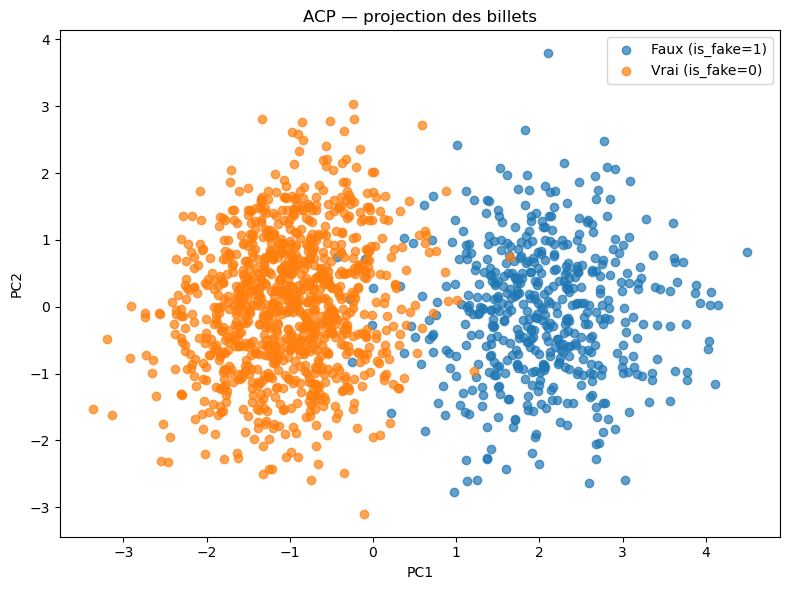

In [33]:
# Variables finales 
features_pca = ["diagonal", "height_left", "height_right", "margin_up", "length", "margin_low"]

# Vérif qu'il n'y ait pas données manquantes
print("NaN par colonne (ACP) :")
print(df[features_pca].isna().sum())

X = df[features_pca].values
y = df["is_fake"].values  # True = 0, False = 1

# Standardisation 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ACP
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

var_ratio = pca.explained_variance_ratio_
print("\nVariance expliquée :")
print(f"PC1 = {var_ratio[0]:.2%}")
print(f"PC2 = {var_ratio[1]:.2%}")
print(f"Cumulée (PC1+PC2) = {var_ratio.sum():.2%}")

# Scatter plot 
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[y==True, 0],  X_pca[y==True, 1],  alpha=0.7, label="Faux (is_fake=1)")
plt.scatter(X_pca[y==False, 0], X_pca[y==False, 1], alpha=0.7, label="Vrai (is_fake=0)")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("ACP — projection des billets")
plt.legend()
plt.tight_layout()
plt.savefig("acp.png", dpi=300, bbox_inches="tight")
plt.show()

Je peux conclure:
- Séparation nette entre classes sur PC1
Il y a deux nuages bien distincts surtout horizontalement :
les faux (orange) sont majoritairement à PC1 négatif
les vrais (bleu) à PC1 positif
- Zone de recouvrement = cas ambigus
Il existe un chevauchement autour de PC1 proche de 0 à 1 :
Ce sont des billets “frontière” qui ressemblent partiellement à l’autre classe et peuvent expliquer les rares erreurs de classification.

In [34]:
# Les coefficients de l'ACP
loadings = pd.DataFrame(
    pca.components_.T,              
    index=features_pca,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

loadings

,PC1,PC2
diagonal,-0.084701,0.941301
height_left,0.330633,0.307537
height_right,0.393562,0.108333
margin_up,0.439421,-0.004952
length,-0.527047,0.048630
margin_low,0.507689,-0.072451


L’ACP indique que la principale source de variance (PC1) est portée par length et margin_low_imputed, variables également les plus discriminantes entre classes ; la seconde composante (PC2) est quasi exclusivement liée à diagonal, qui contribue davantage à la variabilité globale qu’à la séparation vrai/faux.

## 4) Modélisation

### 4.1) Préparation des données pour les modélisations

In [35]:
# Je fixe X et y
features= ['diagonal', 'height_left', 'height_right', 'margin_up', 'length', 'margin_low']
X= df[features].copy()
y= df['is_fake'].copy()

In [36]:
# Split stratifié pour garder la proportion de faux
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2,  stratify=y, random_state=42)
print("Train:", y_train.value_counts(normalize=True))
print("Test :", y_test.value_counts(normalize=True))

Train: is_fake
0    0.666667
1    0.333333
Name: proportion, dtype: float64
Test : is_fake
0    0.666667
1    0.333333
Name: proportion, dtype: float64


### 4.2) Régression logistique 

In [37]:
# Pipeline
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
])

# Entraînement
logreg.fit(X_train, y_train)

# Prédictions
y_pred = logreg.predict(X_test)
y_proba = logreg.predict_proba(X_test)[:, 1]

# Métriques
acc = accuracy_score(y_test, y_pred)
rec = recall_score(y_test, y_pred, pos_label=1)      
f1  = f1_score(y_test, y_pred, pos_label=1)
auc = roc_auc_score(y_test, y_proba)

print("Logistic Regression")
print(f"Accuracy   : {acc:.4f}")
print(f"Recall faux: {rec:.4f}")
print(f"F1 faux    : {f1:.4f}")
print(f"ROC-AUC    : {auc:.4f}")

print("\nMatrice de confusion (rows=true, cols=pred):")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["vrai (0)", "faux (1)"]))

Logistic Regression
Accuracy   : 0.9900
Recall faux: 0.9700
F1 faux    : 0.9848
ROC-AUC    : 0.9989

Matrice de confusion (rows=true, cols=pred):
[[200   0]
 [  3  97]]

Classification report:
              precision    recall  f1-score   support

    vrai (0)       0.99      1.00      0.99       200
    faux (1)       1.00      0.97      0.98       100

    accuracy                           0.99       300
   macro avg       0.99      0.98      0.99       300
weighted avg       0.99      0.99      0.99       300



In [38]:
# Probabilités par classe (0=VRAI, 1=FAUX)
probas = logreg.predict_proba(X_test)

# Extraire les 2 colonnes
p_vrai = probas[:, 0]  
p_faux = probas[:, 1]  

# Prédiction finale (seuil 0.5 par défaut)
y_pred = logreg.predict(X_test)

df_proba = pd.DataFrame({
    "P(VRAI)": p_vrai,
    "P(FAUX)": p_faux,
    "prediction": y_pred
})

df_proba.head()

,P(VRAI),P(FAUX),prediction
0,0.002670,0.997330,1
1,0.000389,0.999611,1
2,0.993595,0.006405,0
3,0.999497,0.000503,0
4,0.002651,0.997349,1


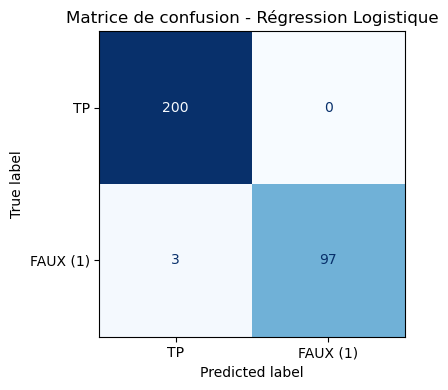

In [39]:
# Matrice de confusion pour la Regression Logistique
cm = confusion_matrix(y_test, y_pred)  

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["TP", "FAUX (1)"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, values_format="d", cmap="Blues", colorbar=False)
ax.set_title("Matrice de confusion - Régression Logistique")
plt.tight_layout()
plt.show()

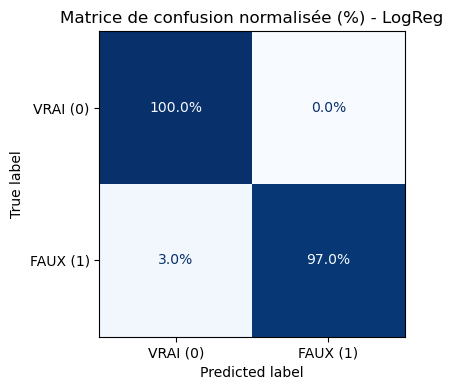

In [40]:
# Matrice de confusion normalisée pour la Regression Logistique
cm_norm = confusion_matrix(y_test, y_pred, normalize="true")  

disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=["VRAI (0)", "FAUX (1)"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, values_format=".1%", cmap="Blues", colorbar=False)
ax.set_title("Matrice de confusion normalisée (%) - LogReg")
plt.tight_layout()
plt.savefig("mat_conf_logreg.png", dpi=300, bbox_inches="tight")
plt.show()

### 4.3) KNN (K-Nearest Neighbors)

In [41]:
k_values = [1, 3, 5, 7, 9, 11, 15, 21]
rows = []

for k in k_values:
    knn = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=k))
    ])
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)
    y_proba = knn.predict_proba(X_test)[:, 1]

    rows.append({
        "k": k,
        "accuracy": accuracy_score(y_test, y_pred),
        "recall_faux": recall_score(y_test, y_pred, pos_label=1),
        "f1_faux": f1_score(y_test, y_pred, pos_label=1),
        "roc_auc": roc_auc_score(y_test, y_proba)
    })

knn_results = pd.DataFrame(rows).sort_values(by="recall_faux", ascending=False)
print(knn_results)

# Choix du meilleur k 
best_k = knn_results.iloc[0]["k"]
print("\nBest k =", best_k)

# Matrice de confusion du meilleur k
best_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier(n_neighbors=int(best_k)))
])
best_knn.fit(X_train, y_train)

y_pred = best_knn.predict(X_test)
print("\nConfusion matrix (best k):\n", confusion_matrix(y_test, y_pred))

    k  accuracy  recall_faux   f1_faux   roc_auc
0   1  0.986667         0.97  0.979798  0.982500
1   3  0.986667         0.97  0.979798  0.984500
2   5  0.986667         0.97  0.979798  0.984325
3   7  0.986667         0.97  0.979798  0.984075
4   9  0.990000         0.97  0.984772  0.984025
5  11  0.990000         0.97  0.984772  0.983950
6  15  0.990000         0.97  0.984772  0.993250
7  21  0.990000         0.97  0.984772  0.998400

Best k = 1.0

Confusion matrix (best k):
 [[199   1]
 [  3  97]]


In [42]:
# Probabilités par classe (0=VRAI, 1=FAUX)
probas = knn.predict_proba(X_test)

# Extraire les 2 colonnes
p_vrai = probas[:, 0]  
p_faux = probas[:, 1]   

# Prédiction finale 
y_pred = knn.predict(X_test)

df_proba = pd.DataFrame({
    "P(VRAI)": p_vrai,
    "P(FAUX)": p_faux,
    "prediction": y_pred
})

df_proba.head()

,P(VRAI),P(FAUX),prediction
0,0.047619,0.952381,1
1,0.000000,1.000000,1
2,1.000000,0.000000,0
3,1.000000,0.000000,0
4,0.000000,1.000000,1


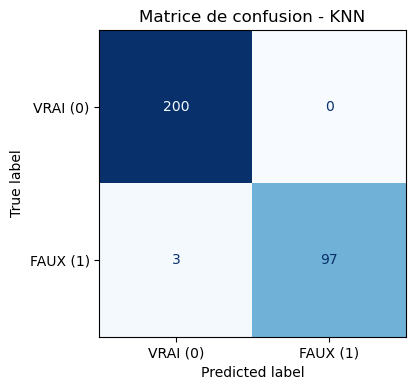

In [43]:
# Matrice de confusion pour K-Nearest Neighbors 
cm_knn = confusion_matrix(y_test, y_pred) 

disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=["VRAI (0)", "FAUX (1)"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, values_format="d", cmap="Blues", colorbar=False)
ax.set_title("Matrice de confusion - KNN")
plt.tight_layout()
plt.show()

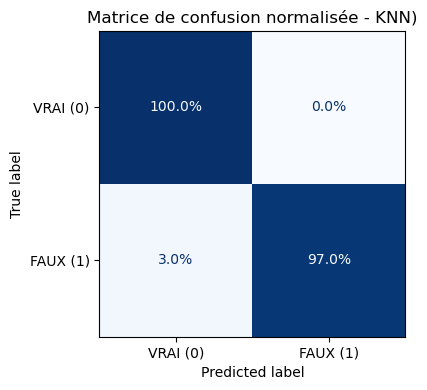

In [44]:
# Matrice de confusion normalisée pour K-Nearest Neighbors 
cm_knn = confusion_matrix(y_test, y_pred)
fp = cm_knn[0, 1]
fn = cm_knn[1, 0]

cm_knn_norm = confusion_matrix(y_test, y_pred, normalize="true")

disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn_norm, display_labels=["VRAI (0)", "FAUX (1)"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, values_format=".1%", cmap="Blues", colorbar=False)
ax.set_title(f"Matrice de confusion normalisée - KNN)")
plt.tight_layout()
plt.savefig("mat_conf_knn.png", dpi=300, bbox_inches="tight")
plt.show()

Best k = 1 car les recall_faux sont identiques, pareil pour les f1_score donc je me base sur le meilleur roc_auc

### 4.4) RF (Random Forest)

In [45]:
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
rec = recall_score(y_test, y_pred, pos_label=1)   
f1  = f1_score(y_test, y_pred, pos_label=1)
auc = roc_auc_score(y_test, y_proba)

print("Random Forest")
print(f"Accuracy   : {acc:.4f}")
print(f"Recall faux: {rec:.4f}")
print(f"F1 faux    : {f1:.4f}")
print(f"ROC-AUC    : {auc:.4f}")

print("\nMatrice de confusion (rows=true, cols=pred):")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["vrai (0)", "faux (1)"]))

Random Forest
Accuracy   : 0.9867
Recall faux: 0.9700
F1 faux    : 0.9798
ROC-AUC    : 0.9989

Matrice de confusion (rows=true, cols=pred):
[[199   1]
 [  3  97]]

Classification report:
              precision    recall  f1-score   support

    vrai (0)       0.99      0.99      0.99       200
    faux (1)       0.99      0.97      0.98       100

    accuracy                           0.99       300
   macro avg       0.99      0.98      0.98       300
weighted avg       0.99      0.99      0.99       300



In [46]:
# Probabilités par classe (0=VRAI, 1=FAUX)
probas = rf.predict_proba(X_test)

# Extraire les 2 colonnes
p_vrai = probas[:, 0]   
p_faux = probas[:, 1]   

# Prédiction finale 
y_pred = rf.predict(X_test)

df_proba = pd.DataFrame({
    "P(VRAI)": p_vrai,
    "P(FAUX)": p_faux,
    "prediction": y_pred
})

df_proba.head()

,P(VRAI),P(FAUX),prediction
0,0.030,0.970,1
1,0.024,0.976,1
2,1.000,0.000,0
3,1.000,0.000,0
4,0.006,0.994,1


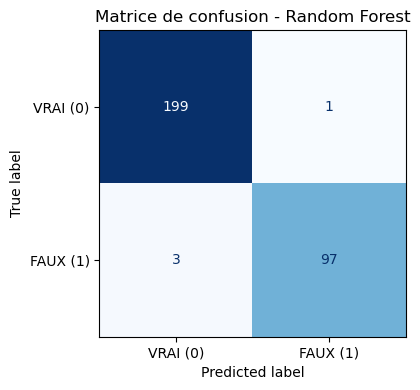

In [47]:
# Matrice de confusion pour RandomForest 
cm_rf = confusion_matrix(y_test, y_pred)  

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["VRAI (0)", "FAUX (1)"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, values_format="d", cmap="Blues", colorbar=False)
ax.set_title("Matrice de confusion - Random Forest")
plt.tight_layout()
plt.show()

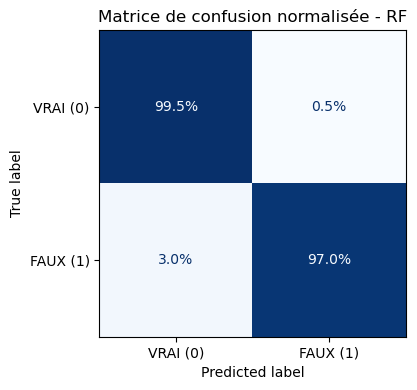

In [48]:
# Matrice de confusion normalisée pour RandomForest 
cm_rf = confusion_matrix(y_test, y_pred)
fp = cm_rf[0, 1]
fn = cm_rf[1, 0]

cm_rf_norm = confusion_matrix(y_test, y_pred, normalize="true")

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf_norm, display_labels=["VRAI (0)", "FAUX (1)"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, values_format=".1%", cmap="Blues", colorbar=False)
ax.set_title(f"Matrice de confusion normalisée - RF")
plt.tight_layout()
plt.savefig("mat_conf_rf.png", dpi=300, bbox_inches="tight")
plt.show()

### 4.5) K-means (clustering non supervisé)

In [49]:
# Scaling 
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# KMeans
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X_train_s)

# Cluster 
train_clusters = kmeans.predict(X_train_s)
cluster_to_label = {}
cluster_to_proba = {}

for c in np.unique(train_clusters):
    y_c = y_train.values[train_clusters == c]
    p_fake = y_c.mean()               
    cluster_to_proba[c] = p_fake
    cluster_to_label[c] = int(p_fake >= 0.5)

# Prédiction sur test
test_clusters = kmeans.predict(X_test_s)
y_pred = np.array([cluster_to_label[c] for c in test_clusters])
y_proba = np.array([cluster_to_proba[c] for c in test_clusters])

# Métriques
acc = accuracy_score(y_test, y_pred)
rec = recall_score(y_test, y_pred, pos_label=1)
f1  = f1_score(y_test, y_pred, pos_label=1)
auc = roc_auc_score(y_test, y_proba)

print(" KMeans (centroides -> classe)")
print(f"Accuracy   : {acc:.4f}")
print(f"Recall faux: {rec:.4f}")
print(f"F1 faux    : {f1:.4f}")
print(f"ROC-AUC    : {auc:.4f}")

print("\nMatrice de confusion (rows=true, cols=pred):")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["vrai (0)", "faux (1)"]))

print("\nMapping cluster -> classe:", cluster_to_label)
print("Proba faux par cluster:", cluster_to_proba)

C:\Users\julie\.anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


 KMeans (centroides -> classe)
Accuracy   : 0.9867
Recall faux: 0.9700
F1 faux    : 0.9798
ROC-AUC    : 0.9825

Matrice de confusion (rows=true, cols=pred):
[[199   1]
 [  3  97]]

Classification report:
              precision    recall  f1-score   support

    vrai (0)       0.99      0.99      0.99       200
    faux (1)       0.99      0.97      0.98       100

    accuracy                           0.99       300
   macro avg       0.99      0.98      0.98       300
weighted avg       0.99      0.99      0.99       300


Mapping cluster -> classe: {0: 1, 1: 0}
Proba faux par cluster: {0: 0.9773869346733668, 1: 0.01371571072319202}


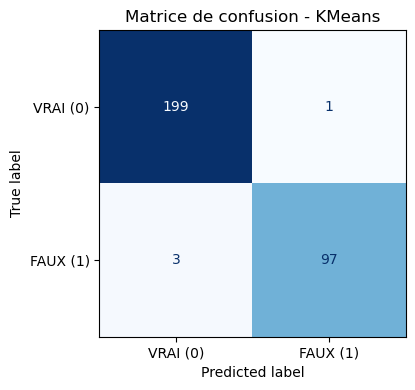

In [50]:
# Matrice de confusion pour Kmeans 
cm_km = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_km, display_labels=["VRAI (0)", "FAUX (1)"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, values_format="d", cmap="Blues", colorbar=False)
ax.set_title("Matrice de confusion - KMeans")
plt.tight_layout()
plt.show()

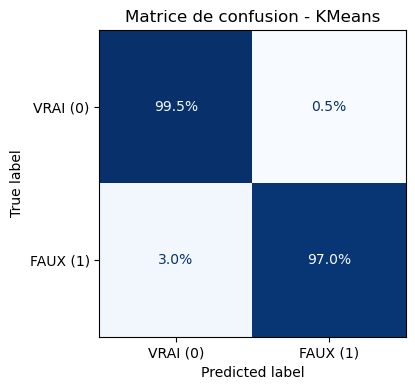

In [51]:
# Matrice de confusion normalisée pour Kmeans 
cm_km = confusion_matrix(y_test, y_pred)
fp = cm_km[0, 1]
fn = cm_km[1, 0]

cm_km_norm = confusion_matrix(y_test, y_pred, normalize="true")

disp = ConfusionMatrixDisplay(confusion_matrix=cm_km_norm, display_labels=["VRAI (0)", "FAUX (1)"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, values_format=".1%", cmap="Blues", colorbar=False)
ax.set_title(f"Matrice de confusion - KMeans")
plt.tight_layout()
plt.savefig("mat_conf_kmeans.png", dpi=300, bbox_inches="tight")
plt.show()

## 5) Comparaison des modèles

In [52]:
comparaison = pd.DataFrame([
    {"Modèle": "LogReg", "Accuracy": 0.9900, "Recall faux": 0.9700, "F1 faux": 0.9848, "ROC-AUC": 0.9989},
    {"Modèle": "KNN", "Accuracy": 0.9867, "Recall faux": 0.9700, "F1 faux": 0.9798, "ROC-AUC": 0.9825},
    {"Modèle": "Random Forest", "Accuracy": 0.9867, "Recall faux": 0.9700, "F1 faux": 0.9798, "ROC-AUC": 0.9989},
    {"Modèle": "KMeans", "Accuracy": 0.9867, "Recall faux": 0.9700, "F1 faux": 0.9798, "ROC-AUC": 0.9825},
]).sort_values(["Recall faux", "ROC-AUC", "F1 faux"], ascending=False)

comparaison

,Modèle,Accuracy,Recall faux,F1 faux,ROC-AUC
0,LogReg,0.9900,0.97,0.9848,0.9989
2,Random Forest,0.9867,0.97,0.9798,0.9989
1,KNN,0.9867,0.97,0.9798,0.9825
3,KMeans,0.9867,0.97,0.9798,0.9825


Les quatre approches obtiennent des performances élevées. Le rappel des faux billets est identique (0.97) pour tous les modèles ; le choix se fait donc sur la qualité globale de discrimination (ROC-AUC) et la stabilité. La régression logistique et la Random Forest affichent les meilleurs ROC-AUC (0.9989), nettement supérieurs à KNN et KMeans (0.9825). Parmi ces deux modèles, la régression logistique présente la meilleure accuracy (0.990) et F1 faux (0.9848), tout en restant plus simple et plus interprétable.

## 6) Choix final

Je retiens la régression logistique comme modèle final : performances maximales, modèle parcimonieux, interprétable (coefficients) et facile à déployer. La Random Forest est une alternative robuste avec un ROC-AUC équivalent, mais moins interprétable. KNN et KMeans sont moins performants en ROC-AUC et plus sensibles aux choix de paramètres / à la structure des données.

## 7) Exportation du modèle

In [53]:
# Sauvegarde du pipeline entraîné 
joblib.dump(logreg, "modele_logreg.joblib")

# Sauvegarde de l'ordre des variables 
features = list(X_train.columns)   
with open("features.json", "w") as f:
    json.dump(features, f)